In [28]:
# Basic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data installation
import os
import requests

# Preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# SVM
from sklearn.svm import SVC

# KNN
from sklearn.neighbors import KNeighborsClassifier

# Tree
from sklearn.tree import DecisionTreeClassifier

## Part 1

### Visualization

In [2]:
directory = 'Training'
dirs = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

In [3]:
print(dirs)

['Austen', 'Baum', 'Verne']


In [4]:
corpus = []
authors = []

for directory in dirs:
    author = os.listdir(f"Training/{directory}")
    for book in author:
        all_words = ''
        # Read files
        with open(f"Training/{directory}/{book}", 'r', encoding='utf-8') as f:
            # Reads the entire file as one big string
            all_words = f.read()
        corpus.append(all_words)
        authors.append(directory)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(corpus)

pca_results = PCA(n_components=2).fit_transform(tfidf.toarray())

In [5]:
print(authors)
print(pca_results)

['Austen', 'Austen', 'Austen', 'Austen', 'Baum', 'Baum', 'Baum', 'Baum', 'Verne', 'Verne', 'Verne', 'Verne']
[[-0.28073346 -0.33018991]
 [-0.27105073 -0.33316677]
 [-0.30439932 -0.33873216]
 [-0.30975137 -0.39868176]
 [ 0.4498929   0.02531968]
 [ 0.60053749  0.01228354]
 [ 0.59846538 -0.00267145]
 [ 0.55761382  0.00430825]
 [-0.3282717   0.61362776]
 [-0.24605514 -0.01924699]
 [-0.33226097  0.65406999]
 [-0.1339869   0.11307983]]


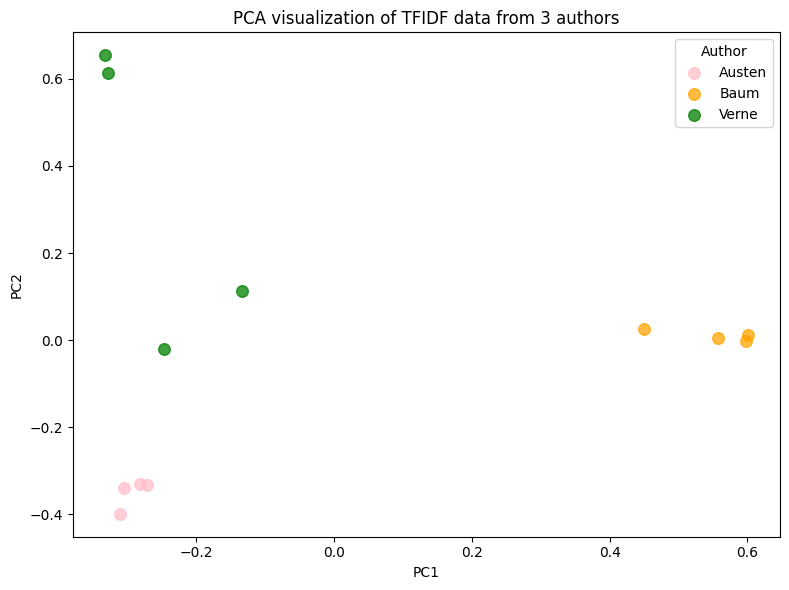

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

unique_authors = sorted(set(authors))
colors = {'Austen': 'pink',
          'Baum': 'orange',
          'Verne': 'green'}

for author in unique_authors:
    mask = [l == author for l in authors]
    pts = pca_results[mask]
    ax.scatter(pts[:, 0], pts[:, 1], label=author, color=colors[author], alpha=0.75, s=70)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Author')
plt.title("PCA visualization of TFIDF data from 3 authors")
plt.tight_layout()
plt.show()

### Prediction

#### Download test data

In [ ]:
# Download the .txt file from the url for each author
# Austen
# url = 'https://www.gutenberg.org/cache/epub/158/pg158.txt'
# response = requests.get(url)

# if response.status_code == 200:
#     with open('Emma.txt', 'wb') as file:
#         file.write(response.content)

# Baum
# url = 'https://www.gutenberg.org/cache/epub/50194/pg50194.txt'
# response = requests.get(url)

# if response.status_code == 200:
#     with open('The_Magic_of_Oz.txt', 'wb') as file:
#         file.write(response.content)


# Verne
# url = 'https://www.gutenberg.org/cache/epub/164/pg164.txt'
# response = requests.get(url)

# if response.status_code == 200:
#     with open('Twenty_Thousand_Leagues_under_the_Sea.txt', 'wb') as file:
#         file.write(response.content)

In [ ]:
# Building naive bayes model
directory = 'Training'
dirs = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

corpus = []
authors = []

for directory in dirs:
    author = os.listdir(f"Training/{directory}")
    for book in author:
        all_words = ''
        # Read files
        with open(f"Training_for_part2_for_part2_for_part2_for_part2_for_part2_for_part2_for_part2_for_part2/{directory}/{book}", 'r', encoding='utf-8') as f:
            # Reads the entire file as one big string
            all_words = f.read()
        corpus.append(all_words)
        authors.append(directory)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_train = vectorizer.fit_transform(corpus)

#### Naive Bayes

In [ ]:
# Naive bayes
mnb = MultinomialNB().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = mnb.predict(tfidf_test)
    print(prediction[0])

For Emma.txt, the predicted author is: Austen
For The_Magic_of_Oz.txt, the predicted author is: Baum
For Twenty_Thousand_Leagues_under_the_Sea.txt, the predicted author is: Verne


#### SVM

In [ ]:
# Support Vector Machine Classifier
svmc = SVC().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = svmc.predict(tfidf_test)
    print(prediction[0])

For Emma.txt, the predicted author is: Austen
For The_Magic_of_Oz.txt, the predicted author is: Baum
For Twenty_Thousand_Leagues_under_the_Sea.txt, the predicted author is: Verne


#### KNN

In [ ]:
# KNN Classifier
knnc = KNeighborsClassifier(n_neighbors=3).fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = knnc.predict(tfidf_test)
    print(prediction[0])

For Emma.txt, the predicted author is: Austen
For The_Magic_of_Oz.txt, the predicted author is: Baum
For Twenty_Thousand_Leagues_under_the_Sea.txt, the predicted author is: Verne


#### Decision Tree

In [ ]:
# Desicion tree
tree = DecisionTreeClassifier().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = tree.predict(tfidf_test)
    print(prediction[0])

For Emma.txt, the predicted author is: Austen
For The_Magic_of_Oz.txt, the predicted author is: Baum
For Twenty_Thousand_Leagues_under_the_Sea.txt, the predicted author is: Verne


## Part2

### Visualization

#### Download data

In [67]:
# Download the .txt file from the url for each author

url = 'https://www.gutenberg.org/cache/epub/2638/pg2638.txt'
response = requests.get(url)

if response.status_code == 200:
    with open('The_Idiot.txt', 'wb') as file:
        file.write(response.content)

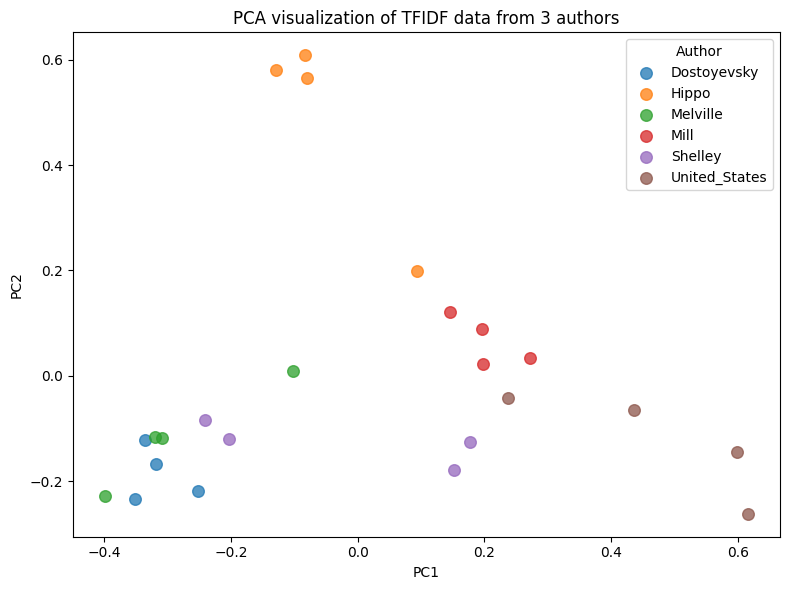

In [ ]:
directory = 'Training_for_part2_for_part2'
dirs = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

corpus = []
authors = []

for directory in dirs:
    author = os.listdir(f"Training_for_part2/{directory}")
    for book in author:
        all_words = ''
        # Read files
        with open(f"Training_for_part2/{directory}/{book}", 'r', encoding='utf-8') as f:
            # Reads the entire file as one big string
            all_words = f.read()
        corpus.append(all_words)
        authors.append(directory)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(corpus)

pca_results = PCA(n_components=2).fit_transform(tfidf.toarray())


# Plot a graph
fig, ax = plt.subplots(figsize=(8, 6))
unique_authors = sorted(set(authors))

for author in unique_authors:
    mask = [l == author for l in authors]
    pts = pca_results[mask]
    ax.scatter(pts[:, 0], pts[:, 1], label=author, alpha=0.75, s=70)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Author')
plt.title("PCA visualization of TFIDF data from 3 authors")
plt.tight_layout()
plt.show()

* Similar
    * Dostoyevsky
    * Melville
    * Shelley

* Different
    * Hippo
    * United_States
    * Dostoyevsky

### Prediction - Similar

In [86]:
# Building naive bayes model
directory = 'Training_for_part2'
dirs = ['Dostoyevsky', 'Melville', 'Shelley']

corpus = []
authors = []

for directory in dirs:
    author = os.listdir(f"Training_for_part2/{directory}")
    for book in author:
        all_words = ''
        # Read files
        with open(f"Training_for_part2/{directory}/{book}", 'r', encoding='utf-8') as f:
            # Reads the entire file as one big string
            all_words = f.read()
        corpus.append(all_words)
        authors.append(directory)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_train = vectorizer.fit_transform(corpus)

In [87]:
# Naive bayes
mnb = MultinomialNB().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = mnb.predict(tfidf_test)
    print(prediction[0])

For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Shelley
For The_Piazza_Tales.txt, the predicted author is: Melville


In [88]:
# Support Vector Machine Classifier
svmc = SVC().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = svmc.predict(tfidf_test)
    print(prediction[0])

For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Shelley
For The_Piazza_Tales.txt, the predicted author is: Melville


In [89]:
# KNN Classifier
knnc = KNeighborsClassifier(n_neighbors=3).fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = knnc.predict(tfidf_test)
    print(prediction[0])

For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Shelley
For The_Piazza_Tales.txt, the predicted author is: Melville


In [90]:
# Desicion tree
tree = DecisionTreeClassifier().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = tree.predict(tfidf_test)
    print(prediction[0])

For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Dostoyevsky
For The_Piazza_Tales.txt, the predicted author is: Melville


#### Prediction - Different

In [91]:
# Building naive bayes model
directory = 'Training_for_part2'
dirs = ['Dostoyevsky', 'Hippo', 'United_states']

corpus = []
authors = []

for directory in dirs:
    author = os.listdir(f"Training_for_part2/{directory}")
    for book in author:
        all_words = ''
        # Read files
        with open(f"Training_for_part2/{directory}/{book}", 'r', encoding='utf-8') as f:
            # Reads the entire file as one big string
            all_words = f.read()
        corpus.append(all_words)
        authors.append(directory)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_train = vectorizer.fit_transform(corpus)

In [92]:
# Naive bayes
mnb = MultinomialNB().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = mnb.predict(tfidf_test)
    print(prediction[0])

For Copyright_Law_of_the_United_States_of_America.txt, the predicted author is: United_states
For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Dostoyevsky
For On_Liberty.txt, the predicted author is: Hippo
For The_Confessions_of_St._Augustine.txt, the predicted author is: Hippo
For The_Piazza_Tales.txt, the predicted author is: Dostoyevsky


In [93]:
# Support Vector Machine Classifier
svmc = SVC().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = svmc.predict(tfidf_test)
    print(prediction[0])

For Copyright_Law_of_the_United_States_of_America.txt, the predicted author is: United_states
For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Dostoyevsky
For On_Liberty.txt, the predicted author is: Hippo
For The_Confessions_of_St._Augustine.txt, the predicted author is: Hippo
For The_Piazza_Tales.txt, the predicted author is: Dostoyevsky


In [94]:
# KNN Classifier
knnc = KNeighborsClassifier(n_neighbors=3).fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = knnc.predict(tfidf_test)
    print(prediction[0])

For Copyright_Law_of_the_United_States_of_America.txt, the predicted author is: United_states
For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: Dostoyevsky
For On_Liberty.txt, the predicted author is: Hippo
For The_Confessions_of_St._Augustine.txt, the predicted author is: Hippo
For The_Piazza_Tales.txt, the predicted author is: Dostoyevsky


In [95]:
# Desicion tree
tree = DecisionTreeClassifier().fit(tfidf_train, authors)

# Load test file
books = os.listdir('Test_for_part2')
for book in books:
    print(f"For {book}, the predicted author is: ", end='')
    all_words = ''
    with open(f'Test_for_part2/{book}', 'r', encoding='utf-8') as f:
        for line in f:
            all_words += line

    tfidf_test = vectorizer.transform([all_words])
    prediction = tree.predict(tfidf_test)
    print(prediction[0])

For Copyright_Law_of_the_United_States_of_America.txt, the predicted author is: United_states
For Crime_and_Punishment.txt, the predicted author is: Dostoyevsky
For Mathilda.txt, the predicted author is: United_states
For On_Liberty.txt, the predicted author is: Hippo
For The_Confessions_of_St._Augustine.txt, the predicted author is: Hippo
For The_Piazza_Tales.txt, the predicted author is: Dostoyevsky
